In [126]:
import warnings
warnings.filterwarnings("ignore")
from RCENSO import *
from XRO import *
import numpy as np
import reservoirpy as rpy
import xarray as xr
rpy.verbosity(0);  # no need to be too verbose here
%config InlineBackend.figure_format = 'retina'

## 1. Data Loading and Train/Test Split

Load the 10 climate-index variables from the ORAS5 reanalysis dataset and split into:

- **Training set**: 1958–1999 (`train_ds`, 42 years / 504 months)
- **Test set**: 2003–2025 (`test_ds`, out-of-sample evaluation period)

The 10 indices — Niño3.4, WWV, NPMM, SPMM, IOB, TNA, ATL3, IOD, SIOD, SASD — span ENSO-related modes across the Pacific, Indian, and Atlantic basins (Fig. 1a of the paper).

In [127]:
ds = xr.open_dataset('data\oras5_indices_1958-2025.nc',engine='netcdf4')
ds = standardize_time_to_month_start(ds)
ds = ds[['Nino34', 'WWV'] + [v for v in ds.data_vars if v not in ('Nino34', 'WWV')]]
train_ds = ds.sel(time=slice('1958-01-01','1999-12-01'))
test_ds = ds.sel(time=slice('2003-01-01','2025-12-01'))
nmembers = 1 # 模型成员数

## 2. Build Input Matrix

Convert the xarray Dataset to a numpy matrix `TS` with fixed column order (Niño3.4 first, then WWV, then the 8 inter-basin modes). `tl = len(train_ds.time)` records the training length used as the train/test split index throughout.

Sinusoidal temporal-period (TP) features (annual + semi-annual cycles, `order=2`) are appended via `pack_TS_anualTP`, giving the full input array `TS_TP` fed to the reservoir.

In [140]:
tl = len(train_ds.time.values)

TS = ds.to_array().values.T

TS_TP_anual = pack_TS_anualTP(TS,order=2)
time = ds.time
t = np.arange(len(time))

## 3. Hyperparameter Configuration

Two DESN architectures are evaluated (Fig. 2c–e):

| Parameter | Single-layer `n_l=1` | Two-layer `n_l=2` |
|-----------|---------------------|-------------------|
| Reservoir size | 20 000 | [20 000, 12 000] |
| Leaking rate α | 1 | [1, 1] |
| Spectral radius | 1 | [1, 1] |
| Input connectivity | 0.10 | [0.10, 0.10] |
| Reservoir noise | 0.05 | [0.05, 0] |
| Ridge regularisation | 5×10⁻⁶ | 5×10⁻⁶ |
| IP adaptation | Yes (layer 1) | Yes (layer 1) |

The ensemble mean over both architectures forms the final **DESN** prediction reported in the paper.

In [ ]:
model_types=[r'DESN($n_l=1$)',r'DESN($n_l=2$)']
hypers={
    model_types[0]:{
        'units':20000,
        'lr':1,
        'sr':1,
        'rc_connectivity':0.0,
        'input_connectivity':0.10,
        'input_scaling': 1,
        'ridge':5e-6,
        'noise_rc':0.05,
        'noise_in':0,
        'output_dim':TS.shape[1],
        'seed': None,
        'use_raw_input':True,
        'ip_reservoir':True,
    },
    model_types[1]:{
        'units':[20000,12000],
        'lr':[1,1],
        'sr':[1,1],
        'rc_connectivity':[0,0],
        'input_connectivity':[0.1,0.1],
        'input_scaling':[1,1],
        'ridge':5e-6,
        'noise_rc':[0.05,0],
        'noise_in':[0,0],
        'output_dim':TS.shape[1],
        'seed': None,
        'deep':True,
        'deep_ip_list':[True,False]
    },
}

## 4. DESN Ensemble Training and Forecast

For each architecture, `TPRC_Forecast_Train_Test_Ensemble` trains `nmembers` independent reservoir instances on the training period and rolls out 20-month forecasts over the test set. The TP encoding is updated at every recursive step. The ensemble means from both architectures are averaged into a single **DESN** prediction.

In [130]:
Ypred_mean = {}
ensemble_predictions = {}
for model_type in model_types:
    Ypred_mean[model_type], Ytest, ensemble_predictions[model_type] = TPRC_Forecast_Train_Test_Ensemble(TS=TS,
                                                                         tl=tl,
                                                                         dl=0,
                                                                         wl=36,
                                                                         hypers=hypers[model_type],
                                                                         steps=20,
                                                                         nmember=nmembers,
                                                                         isReforecast=False)

  0%|          | 0/1 [00:00<?, ?it/s]

Layer 1: units=28000, sr=1, lr=1, ip_reservoir=True
Layer 2: units=12000, sr=1, lr=1, ip_reservoir=False


100%|██████████| 1/1 [06:35<00:00, 395.04s/it]


In [131]:
nm_fcst = np.concatenate([ensemble_predictions[model_type] for model_type in model_types],axis=0)
Ensemble_Fcst = nm_fcst.mean(axis=0)
Ypred_mean['DESN'] = Ensemble_Fcst

## 5. XRO Benchmark Forecast

The XRO (eXtended nonlinear Recharge Oscillator) model serves as the physics-based benchmark. It is fitted with annual and semi-annual cycle terms (`ac_order=2`) and nonlinear terms restricted to Niño3.4 and IOD (`maskb`). Deterministic reforecasts (`noise_type='zero'`) are generated over the test period for direct comparison with DESN.

In [132]:
# XRO model with annual mean, annual cycle, and semi-annual cycle
XROac2 = XRO(ncycle=12, ac_order=2)
# XRO model used as control experiment in the paper
XROac2_fit = XROac2.fit_matrix(train_ds, maskb=['Nino34', 'IOD'])
XROac2_fcst = XROac2.reforecast(fit_ds=XROac2_fit, init_ds=test_ds, n_month=19, ncopy=1, noise_type='zero')
Ypred_mean['XRO'] = XROac2_fcst.to_array().values.transpose(1,0,2)

## 6. Forecast Skill Evaluation (Fig. 2)

Pearson correlation and RMSE are computed as a function of lead time for each of the 10 climate modes using `ndforecast_skill`. The Niño3.4 skill curves for DESN and XRO are plotted and compared, reproducing the out-of-sample forecast skill panel of Fig. 2 in the paper.

In [133]:
climate_modes = ['Nino34', 'WWV', 'NPMM', 'SPMM', 'IOB', 'TNA', 'ATL3', 'IOD', 'SIOD', 'SASD']

corr = {}
rmse = {}
for model_name in Ypred_mean.keys():
    corr[model_name] = {}
    rmse[model_name] = {}
    for i, mode in enumerate(climate_modes):
        corr[model_name][mode], rmse[model_name][mode] = ndforecast_skill(
            Ypred_mean[model_name], Ytest, showdim=i, ismv3=True, wl=0)

In [138]:
plot_keys = ['XRO','DESN',]
corr_to_plot = {k: corr[k]['Nino34'] for k in plot_keys}
rmse_to_plot = {k: rmse[k]['Nino34'] for k in plot_keys}
styles = {'DESN': {'color': 'deepskyblue','marker': 'o','linewidth':3, 'markersize':6},
          'XRO': {'color': 'gray','marker': '','linewidth':3,'alpha':0.8},
          }

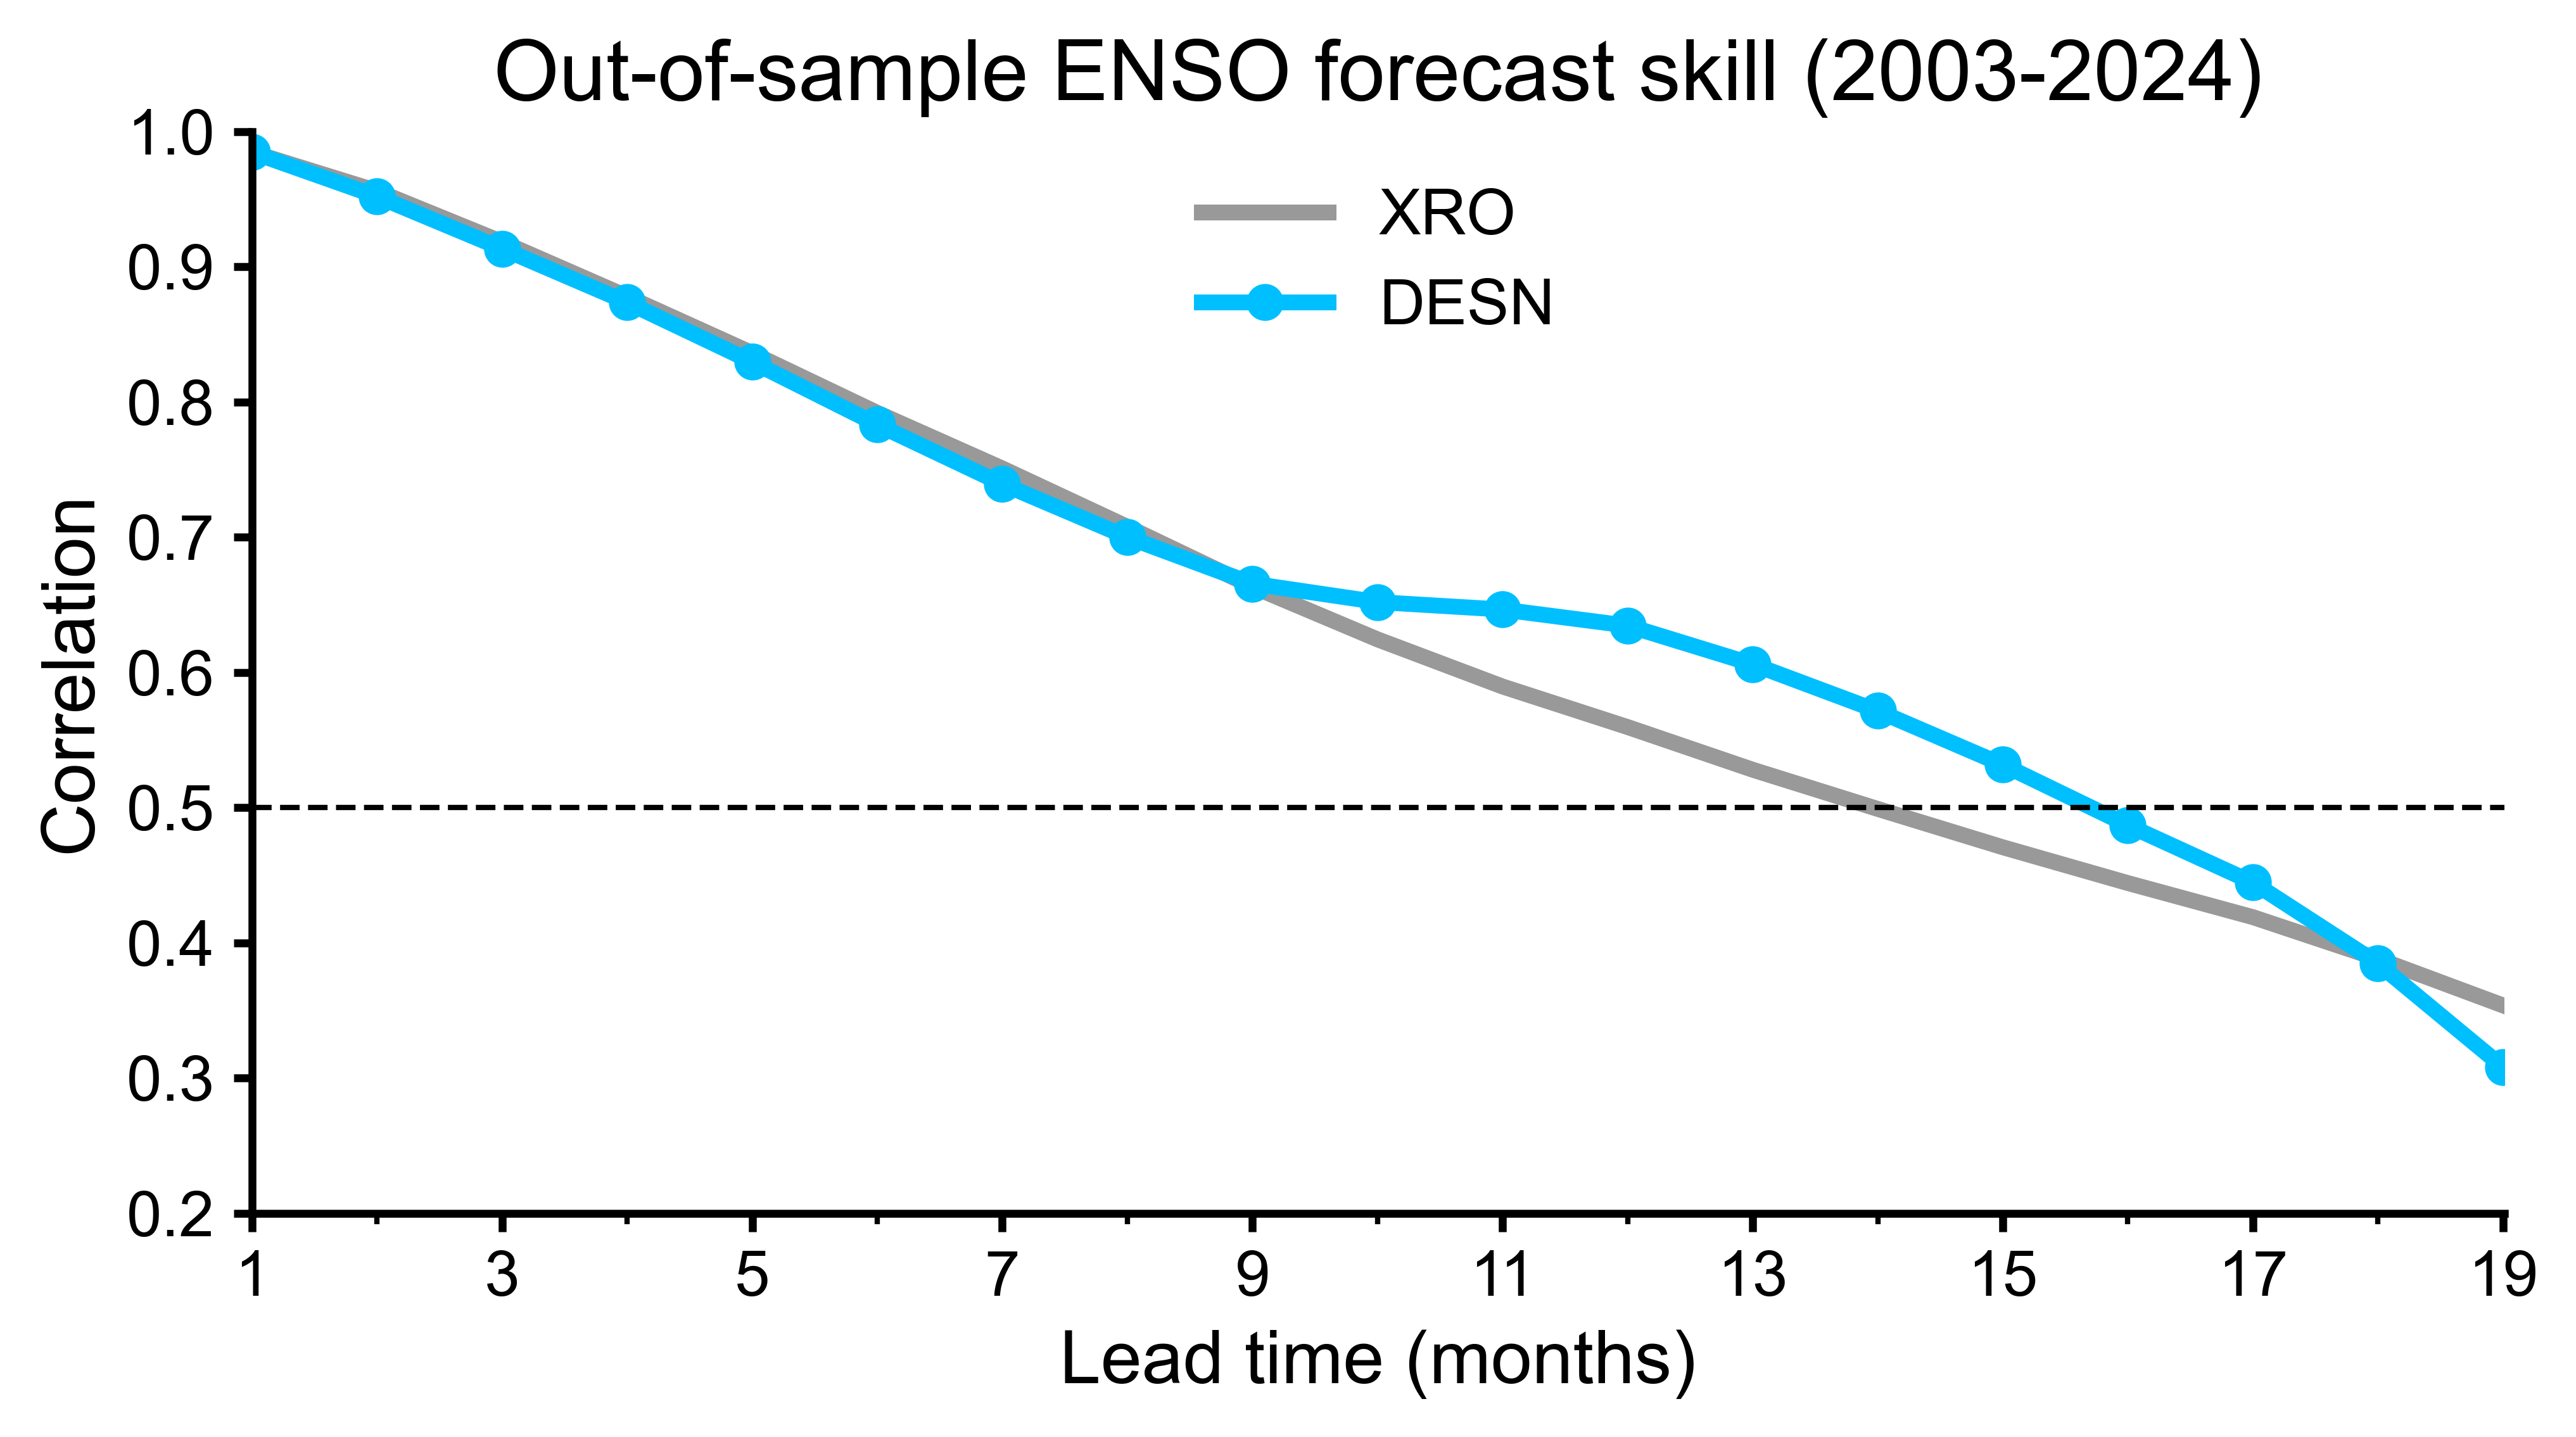

In [139]:
plot_main_skills_with_legend(corr_to_plot,
                             styles=styles,
                             grid_on=False,
                             legend=True,
                             legend_in_main=True,
                             figsize=(7,4), 
                             ylim=(0.2,1.),
                             xlim=(1,19.01),
                             skill_name='Correlation',
                             title='Out-of-sample ENSO forecast skill (2003-2024)')
